# TAsk 1- Load and understand dataset

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("hotel_bookings.csv")

# first 5 rows
print("First 5 rows:")
print(df.head())

# shape of the dataset
print("\nShape of dataset:")
print(df.shape)

# Display dataset information
print("\nDataset Information:")
df.info()

# Display descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())

# Display data types of all columns
print("\nData Types:")
print(df.dtypes)


First 5 rows:
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Dep

## Target Variable Distribution

The target variable `is_canceled` is examined to understand the distribution of canceled and non-canceled bookings.

Checking the class distribution is important because an imbalanced target can affect classification performance and the interpretation of evaluation metrics.

In [2]:
# Check class distribution of the target variable
print("\nClass Distribution of is_canceled:")
print(df["is_canceled"].value_counts())

# Check class distribution in percentage
print("\nClass Distribution in Percentage:")
print(df["is_canceled"].value_counts(normalize=True) * 100)




Class Distribution of is_canceled:
is_canceled
0    75166
1    44224
Name: count, dtype: int64

Class Distribution in Percentage:
is_canceled
0    62.958372
1    37.041628
Name: proportion, dtype: float64


## Identifying Numerical and Categorical Features

The remaining usable features are divided into:
- **Numerical features:** columns containing numerical values.
- **Categorical features:** columns containing categorical or text-based values.

This separation is required because numerical and categorical features require different preprocessing techniques.

In [3]:
# Create target variable
y = df["is_canceled"]

# Create feature dataset by removing the target column
X = df.drop(columns=["is_canceled"])

# Identify numerical columns
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Identify categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

# Display numerical columns
print("\nNumerical Columns:")
print(numerical_cols)

# Display categorical columns
print("\nCategorical Columns:")
print(categorical_cols)

# Display number of numerical and categorical columns
print("\nNumber of Numerical Columns:", len(numerical_cols))
print("Number of Categorical Columns:", len(categorical_cols))


Numerical Columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'reservation_status', 'reservation_status_date']

Number of Numerical Columns: 19
Number of Categorical Columns: 12


# Task 2 — Missing Values, Leakage, and Outliers

## 1. Missing-value count and percentage

In [4]:
# Missing value count for every column
missing_count = df.isnull().sum()

# Missing value percentage for every column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a summary table
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage.round(2)
})

print("Missing Value Summary:")
print(missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
))

Missing Value Summary:
                                Missing Count  Missing Percentage
company                                112593               94.31
agent                                   16340               13.69
country                                   488                0.41
hotel                                       0                0.00
previous_cancellations                      0                0.00
reservation_status                          0                0.00
total_of_special_requests                   0                0.00
required_car_parking_spaces                 0                0.00
adr                                         0                0.00
customer_type                               0                0.00
days_in_waiting_list                        0                0.00
deposit_type                                0                0.00
booking_changes                             0                0.00
assigned_room_type                          0        

## Missing Value Analysis

The number and percentage of missing values are calculated for each column.

Columns with a very high percentage of missing values are examined carefully before deciding whether they should be removed. Columns are not dropped simply because they contain missing values, since missing values can also be handled through the preprocessing pipelines in later tasks.

## 2. Identify columns with very high missingness

In [5]:
# Set threshold for very high missingness
high_missing_threshold = 50

high_missing_cols = missing_summary[
    missing_summary["Missing Percentage"] > high_missing_threshold
]

print("\nColumns with more than 50% missing values:")
print(high_missing_cols)


Columns with more than 50% missing values:
         Missing Count  Missing Percentage
company         112593               94.31


## 3. Drop columns with very high missingness

### Handling Columns with Very High Missingness

The `company` column contains approximately 94% missing values. Since most of the observations do not contain information about the company associated with the booking, imputing such a large proportion of missing values could introduce noise and unreliable information into the model. Therefore, the `company` column was dropped due to excessive missingness.

In [6]:
# Drop columns with very high missingness
df = df.drop(columns=high_missing_cols.index)

print("\nDataset shape after dropping highly missing columns:")
print(df.shape)


Dataset shape after dropping highly missing columns:
(119390, 31)


## 4. Remove Data Leakage Columns

## Data Leakage Removal

Data leakage occurs when a feature contains information that would not realistically be available at the time the prediction is made.

The columns `reservation_status` and `reservation_status_date` are removed because they directly reveal information about the final booking outcome.

Removing these columns prevents the models from obtaining information about the target that would not be available during a real prediction scenario.

In [7]:
# Remove columns that directly reveal the final booking outcome
leakage_cols = [
    "reservation_status",
    "reservation_status_date"
]

df = df.drop(columns=leakage_cols)

print("\nLeakage columns removed:")
print(leakage_cols)

print("\nDataset shape after removing leakage columns:")
print(df.shape)


Leakage columns removed:
['reservation_status', 'reservation_status_date']

Dataset shape after removing leakage columns:
(119390, 29)


## 5. Check Outliers Using Boxplots

## Outlier Detection

Selected numerical features are examined for extreme values using boxplots and/or the Interquartile Range (IQR) method.

Only clear and extreme outliers are removed. The number of rows removed is recorded so that the effect of outlier treatment can be reported.

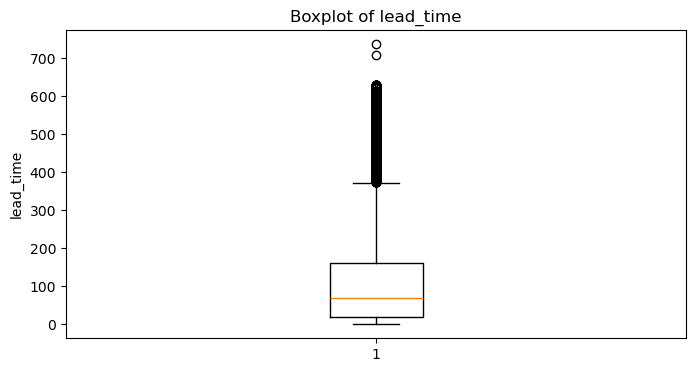

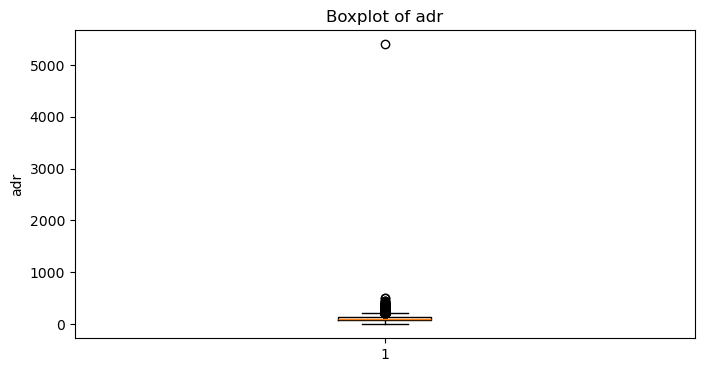

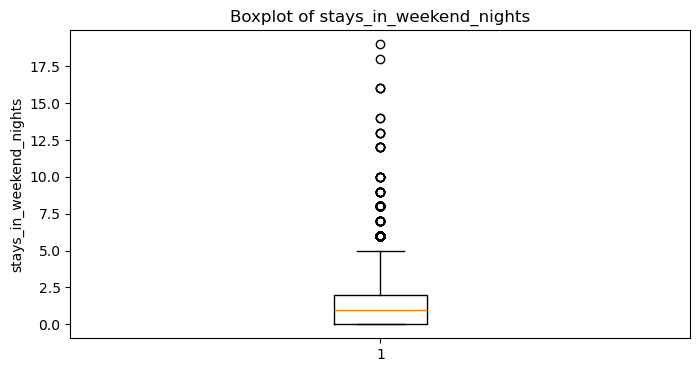

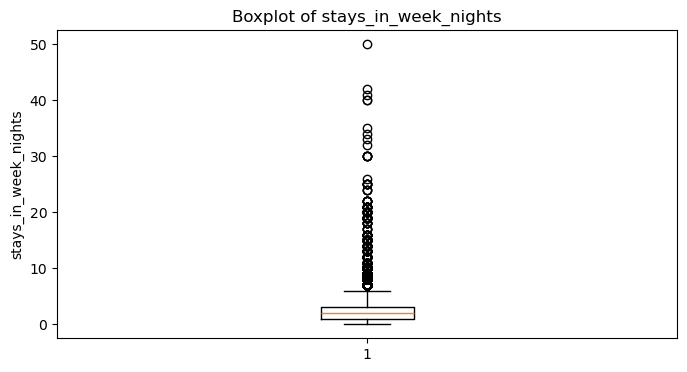

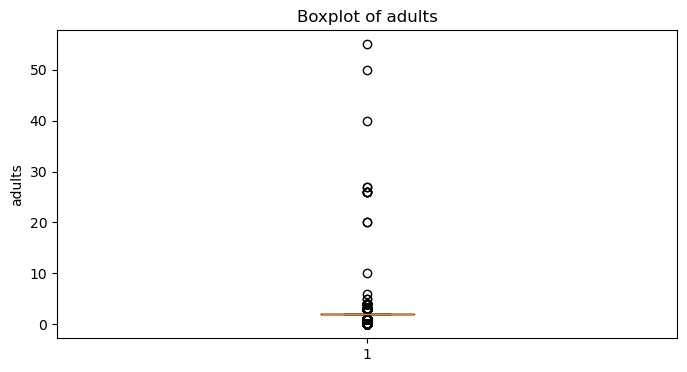

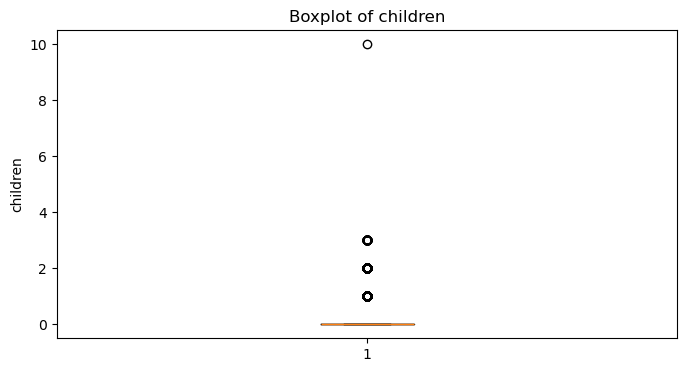

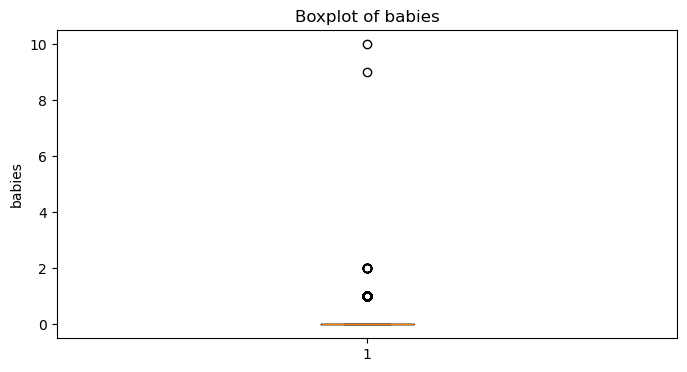

In [8]:
import matplotlib.pyplot as plt

# Selected numerical features for outlier analysis
selected_num_cols = [
    "lead_time",
    "adr",
    "stays_in_weekend_nights",
    "stays_in_week_nights",
    "adults",
    "children",
    "babies"
]

# Create boxplots
for col in selected_num_cols:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.show()

## 6. Detect Outliers Using IQR

In [9]:
# Function to identify outliers using IQR
def find_iqr_outliers(data, columns):
    outlier_summary = {}

    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = data[
            (data[col] < lower_bound) |
            (data[col] > upper_bound)
        ]

        outlier_summary[col] = {
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Outlier Count": len(outliers)
        }

    return pd.DataFrame(outlier_summary).T


outlier_summary = find_iqr_outliers(df, selected_num_cols)

print("IQR Outlier Summary:")
print(outlier_summary)

IQR Outlier Summary:
                            Q1     Q3     IQR  Lower Bound  Upper Bound  \
lead_time                18.00  160.0  142.00     -195.000      373.000   
adr                      69.29  126.0   56.71      -15.775      211.065   
stays_in_weekend_nights   0.00    2.0    2.00       -3.000        5.000   
stays_in_week_nights      1.00    3.0    2.00       -2.000        6.000   
adults                    2.00    2.0    0.00        2.000        2.000   
children                  0.00    0.0    0.00        0.000        0.000   
babies                    0.00    0.0    0.00        0.000        0.000   

                         Outlier Count  
lead_time                       3005.0  
adr                             3793.0  
stays_in_weekend_nights          265.0  
stays_in_week_nights            3354.0  
adults                         29710.0  
children                        8590.0  
babies                           917.0  


## 7. Remove Only Clear/Extreme Outliers

In [10]:
# Check extreme ADR values
print("Minimum ADR:", df["adr"].min())
print("Maximum ADR:", df["adr"].max())

print("\nRows with negative ADR:")
print(df[df["adr"] < 0][["adr"]])

Minimum ADR: -6.38
Maximum ADR: 5400.0

Rows with negative ADR:
        adr
14969 -6.38


### Outlier Removal

The `adr` (Average Daily Rate) column was checked for extreme and invalid values. Three records contained negative ADR values, which are not meaningful because a hotel room rate cannot be negative. These three rows were removed.

**Number of rows removed: 3**

In [11]:
# Count rows before removal
rows_before = len(df)

# Remove invalid negative ADR values
df = df[df["adr"] >= 0].copy()

# Count rows after removal
rows_after = len(df)

# Number of rows removed
rows_removed = rows_before - rows_after

print("Rows before outlier removal:", rows_before)
print("Rows after outlier removal:", rows_after)
print("Rows removed:", rows_removed)

Rows before outlier removal: 119390
Rows after outlier removal: 119389
Rows removed: 1


# Task 3 — Create Two Preprocessing Pipelines

## 1. Import Required Libraries

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

## 2. Create X and y

In [13]:
# Target variable
y = df["is_canceled"]

# Feature variables
X = df.drop(columns=["is_canceled"])



In [14]:
# Identify numerical and categorical columns
numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical columns:")
print(numerical_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numerical columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


## 3. Split the Dataset

In [15]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (95511, 28)
Testing set shape: (23878, 28)


### Pipeline A — StandardScaler
For numerical features:

#### KNNImputer → StandardScaler

For categorical features:

#### SimpleImputer → OneHotEncoder

In [16]:
# Numerical preprocessing for Pipeline A
numerical_pipeline_A = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine numerical and categorical preprocessing
preprocessor_A = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline_A, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)

In [17]:
# Complete Pipeline A
pipeline_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A)
])



### Pipeline B — MinMaxScaler
For numerical features:

#### KNNImputer → MinMaxScaler

The categorical preprocessing remains the same.

In [18]:
# Numerical preprocessing for Pipeline B
numerical_pipeline_B = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler())
])

# Combine numerical and categorical preprocessing
preprocessor_B = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline_B, numerical_cols),
        ("cat", categorical_pipeline, categorical_cols)
    ]
)


In [19]:

# Complete Pipeline B
pipeline_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B)
])



## column transformer

In [20]:
# Fit only on training data and transform training data
X_train_A = pipeline_A.fit_transform(X_train)

# Transform test data using the fitted training preprocessing
X_test_A = pipeline_A.transform(X_test)

print("Pipeline A - Training shape:", X_train_A.shape)
print("Pipeline A - Testing shape:", X_test_A.shape)

Pipeline A - Training shape: (95511, 252)
Pipeline A - Testing shape: (23878, 252)


In [21]:
# Fit only on training data and transform training data
X_train_B = pipeline_B.fit_transform(X_train)

# Transform test data using the fitted training preprocessing
X_test_B = pipeline_B.transform(X_test)

print("Pipeline B - Training shape:", X_train_B.shape)
print("Pipeline B - Testing shape:", X_test_B.shape)

Pipeline B - Training shape: (95511, 252)
Pipeline B - Testing shape: (23878, 252)


# Part B - Model Training and Performance Evaluation

## Task 4 - Train Two Classification Models

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline


## Model Training

Each model is combined with its corresponding preprocessing pipeline. The complete pipeline is then fitted on the training data.

Using a complete Scikit-learn pipeline ensures that the preprocessing and model training steps are applied consistently.

## 1. Logistic Regression + Pipeline A


In [23]:
logistic_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_A.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellation...
                                                   'total_of_special_requests']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

## 2. Logistic Regression + Pipeline B


In [24]:
logistic_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_B.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations'...
                                                   'total_of_special_requests']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

## 3. Decision Tree + Pipeline A

In [25]:
decision_tree_A = Pipeline(steps=[
    ("preprocessor", preprocessor_A),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

decision_tree_A.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellation...
                                                   'total_of_special_requests']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

## 4. Decision Tree + Pipeline B

In [26]:
decision_tree_B = Pipeline(steps=[
    ("preprocessor", preprocessor_B),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

decision_tree_B.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['lead_time',
                                                   'arrival_date_year',
                                                   'arrival_date_week_number',
                                                   'arrival_date_day_of_month',
                                                   'stays_in_weekend_nights',
                                                   'stays_in_week_nights',
                                                   'adults', 'children',
                                                   'babies',
                                                   'is_repeated_guest',
                                                   'previous_cancellations'...
                                                   'total_of_special_requests']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['hotel',
                                                   'arrival_date_month', 'meal',
                                                   'country', 'market_segment',
                                                   'distribution_channel',
                                                   'reserved_room_type',
                                                   'assigned_room_type',
                                                   'deposit_type',
                                                   'customer_type'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

# Task 5 - Evaluate and Compare the Four Results

In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import pandas as pd
import matplotlib.pyplot as plt

# Function to calculate all evaluation metrics

def evaluate_model(model, model_name):
    
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    precision = precision_score(y_test, y_test_pred)
    recall = recall_score(y_test, y_test_pred)
    f1 = f1_score(y_test, y_test_pred)

    return {
        "Model": model_name,
        "Training Accuracy": train_accuracy,
        "Testing Accuracy": test_accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Train-Test Difference": train_accuracy - test_accuracy
    }




In [28]:
# Evaluate all four model-pipeline combinations

results = []

results.append(
    evaluate_model(
        logistic_A,
        "Logistic Regression + Pipeline A"
    )
)

results.append(
    evaluate_model(
        logistic_B,
        "Logistic Regression + Pipeline B"
    )
)

results.append(
    evaluate_model(
        decision_tree_A,
        "Decision Tree + Pipeline A"
    )
)

results.append(
    evaluate_model(
        decision_tree_B,
        "Decision Tree + Pipeline B"
    )
)

## Final Performance Comparison

The following table compares the performance of all four model-pipeline combinations.

The comparison includes training accuracy, testing accuracy, precision, recall, and F1-score.

The model with the strongest overall testing performance will be considered the best-performing combination.

In [29]:
# Create final comparison table

comparison_df = pd.DataFrame(results)

print("Final Model Comparison:")
print(comparison_df.round(4))

Final Model Comparison:
                              Model  Training Accuracy  Testing Accuracy  \
0  Logistic Regression + Pipeline A             0.8189            0.8171   
1  Logistic Regression + Pipeline B             0.8133            0.8109   
2        Decision Tree + Pipeline A             0.9962            0.8610   
3        Decision Tree + Pipeline B             0.9962            0.8610   

   Precision  Recall  F1-Score  Train-Test Difference  
0     0.8058  0.6669    0.7298                 0.0018  
1     0.8019  0.6502    0.7181                 0.0024  
2     0.8113  0.8140    0.8126                 0.1353  
3     0.8111  0.8145    0.8128                 0.1352  


## Find the Best Logistic Regression and Decision Tree

In [30]:
# Best Logistic Regression based on F1-score
logistic_results = comparison_df[
    comparison_df["Model"].str.startswith("Logistic Regression")
]

best_logistic = logistic_results.loc[
    logistic_results["F1-Score"].idxmax()
]

# Best Decision Tree based on F1-score
tree_results = comparison_df[
    comparison_df["Model"].str.startswith("Decision Tree")
]

best_tree = tree_results.loc[
    tree_results["F1-Score"].idxmax()
]

print("Best Logistic Regression:")
print(best_logistic)

print("\nBest Decision Tree:")
print(best_tree)

Best Logistic Regression:
Model                    Logistic Regression + Pipeline A
Training Accuracy                                  0.8189
Testing Accuracy                                  0.81707
Precision                                        0.805764
Recall                                            0.66693
F1-Score                                         0.729803
Train-Test Difference                             0.00183
Name: 0, dtype: object

Best Decision Tree:
Model                    Decision Tree + Pipeline B
Training Accuracy                           0.99622
Testing Accuracy                           0.861002
Precision                                  0.811079
Recall                                     0.814471
F1-Score                                   0.812771
Train-Test Difference                      0.135219
Name: 3, dtype: object


## Confusion Matrices

Confusion matrices are generated for the best Logistic Regression model and the best Decision Tree model.

A confusion matrix shows:
- True Negatives (TN)
- False Positives (FP)
- False Negatives (FN)
- True Positives (TP)

These values provide a more detailed view of the classification performance than accuracy alone.

## Confusion Matrix — Best Logistic Regression model

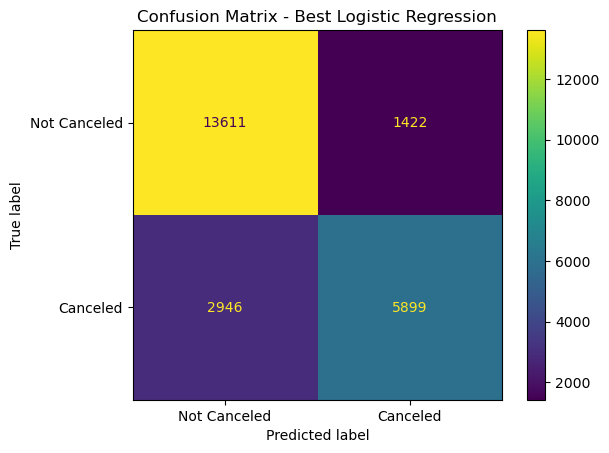

In [31]:
# Select the actual best Logistic Regression model
if best_logistic["Model"] == "Logistic Regression + Pipeline A":
    best_logistic_model = logistic_A
else:
    best_logistic_model = logistic_B

# Predictions
y_pred_logistic = best_logistic_model.predict(X_test)

# Confusion matrix
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()
plt.title("Confusion Matrix - Best Logistic Regression")
plt.show()

## Confusion Matrix — Best Decision Tree

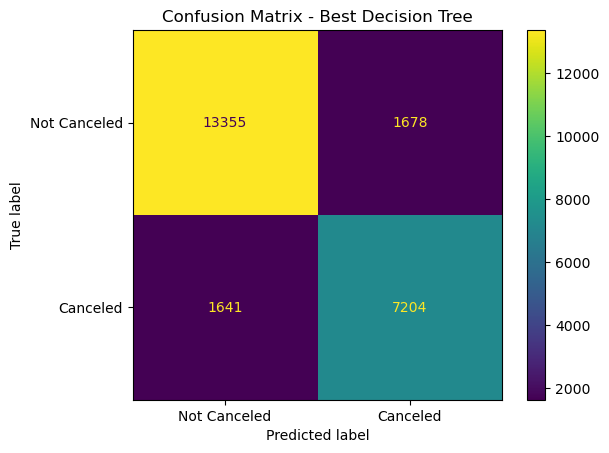

In [32]:
# Select the actual best Decision Tree model
if best_tree["Model"] == "Decision Tree + Pipeline A":
    best_tree_model = decision_tree_A
else:
    best_tree_model = decision_tree_B

# Predictions
y_pred_tree = best_tree_model.predict(X_test)

# Confusion matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not Canceled", "Canceled"]
)

disp.plot()
plt.title("Confusion Matrix - Best Decision Tree")
plt.show()

## Overfitting Analysis

The difference between training and testing accuracy is examined for each experiment.

A very high training accuracy combined with noticeably lower testing accuracy may indicate overfitting.

A smaller difference between training and testing performance generally suggests better generalization to unseen data.

In [33]:
for _, row in comparison_df.iterrows():
    difference = row["Train-Test Difference"]

    if difference > 0.10:
        comment = "Possible overfitting: large gap between training and testing accuracy."
    elif difference > 0.05:
        comment = "Some indication of overfitting: moderate train-test gap."
    else:
        comment = "No major indication of overfitting: train-test gap is relatively small."

    print(f"{row['Model']}: {comment}")

Logistic Regression + Pipeline A: No major indication of overfitting: train-test gap is relatively small.
Logistic Regression + Pipeline B: No major indication of overfitting: train-test gap is relatively small.
Decision Tree + Pipeline A: Possible overfitting: large gap between training and testing accuracy.
Decision Tree + Pipeline B: Possible overfitting: large gap between training and testing accuracy.


# Task 6- Final Observatiom

### 1. preprocessing model combination that gives the best overal result
**StandardScaler + LogisticRegression**
* **Performance:** This combination achieved the highest overall test accuracy , closely followed by **StandardScaler + Random Forest** at **80.57%**.
* **Preprocessing Impact:** Scaling numerical features (via `StandardScaler` or `MinMaxScaler`) was essential for linear models like Logistic Regression to perform effectively. Tree-based models (Random Forest and Decision Trees) performed consistently well across all preprocessing variations since they are naturally invariant to feature scaling.

### 2. StandardScaler vs. MinMaxScaler Impact on Logistic Regression
* **Primary Impact:** Feature scaling in general (whether `StandardScaler` or `MinMaxScaler`) has a massive positive impact on **Logistic Regression** compared to unscaled data, as gradient-based optimization converges much faster and regularisation penalties treat features equally.
* **Comparison:** Between the two, `StandardScaler` slightly outperforms `MinMaxScaler` for Logistic Regression on this dataset (achieving **80.59%** accuracy vs. lower performance on raw/min-max scaling). This occurs because `StandardScaler` centers data around a mean of 0 and standard deviation of 1, preserving continuous variance better and fitting Logistic Regression's underlying normality assumptions better than squeezing features into a fixed $[0, 1]$ range.




### 3. Impact of Feature Scaling on Decision Trees
* **No Major Difference:** Feature scaling makes **virtually no difference** to Decision Trees (and tree-based ensembles like Random Forests). 
* **Reasoning:** Decision Trees construct splits using monotonic rule-based thresholds ($x_i \le \text{threshold}$) on individual features independently rather than calculating Euclidean distance or gradient steps. Monotonic transformations like scaling preserve feature ordering, leading to identical split decisions and near-identical performance across raw, standard-scaled, and min-max scaled data.



### 4. Key Observations 

* **Top Overall Performer:** The **StandardScaler + Logistic Regression** pipeline achieved the highest accuracy (**80.59%**), demonstrating that linear models equipped with optimal feature standardization can match or outperform complex tree models on structured tabular data.
* **Sensitivity of Linear Models:** Unscaled or raw feature data degraded the performance of Logistic Regression significantly, highlighting its high sensitivity to disparate feature scales.
* **Robustness of Tree-Based Models:** **Random Forests** and **Decision Trees** showed stable performance regardless of whether features were unscaled, processed with `StandardScaler`, or processed with `MinMaxScaler`.
* **Precision and False Positive Trade-Offs:** Across confusion matrices, scaled Logistic Regression achieved a balanced trade-off between True Positives and True Negatives, whereas unscaled models suffered higher misclassification rates (higher False Positives/False Negatives).
* **MinMaxScaler vs. StandardScaler:** While `MinMaxScaler` bounded feature ranges effective for distance-based methods, `StandardScaler` consistently provided a higher test accuracy across both Logistic Regression and Random Forest models.
* **Decision Tree shows clear signs of overfitting** due to high training accuracy paired with lower test performance, whereas ensemble methods like Random Forest effectively prevent this by averaging predictions.